# 🧬 Breast Cancer Subtype Classification using Machine Learning

## AI-Assisted Bioinformatics Analysis of Gene Expression Data (GSE45827)

### Project Overview

Breast cancer is a heterogeneous disease consisting of multiple molecular subtypes, including Basal, HER2, Luminal A, Luminal B, Normal, and Cell Line samples. Correct subtype identification is important because different subtypes often require different treatment strategies.

In this project, gene expression data from the GEO database (GSE45827) is analyzed using machine learning. After preprocessing the data, a classification model is trained to predict breast cancer subtypes based on gene expression profiles.

### Objectives

- Load and preprocess a public breast cancer gene expression dataset.
- Extract molecular subtype labels.
- Train a machine learning classifier.
- Evaluate classification performance.
- Identify the most informative genes for subtype prediction.

---

**Dataset:** GSE45827 (NCBI GEO)

**Platform:** Affymetrix Human Genome U133 Plus 2.0 Array

**Programming Language:** Python

**Libraries:** Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

# 1. Import Required Libraries

The following libraries are used for data processing, visualization, machine learning, and model evaluation.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Reading compressed GEO files
import gzip
from io import StringIO

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


# 2. Load the Dataset

The dataset is downloaded from the NCBI Gene Expression Omnibus (GEO). It contains gene expression values for 155 breast tissue samples representing different molecular subtypes.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = "/content/drive/MyDrive/GSE45827_series_matrix.txt.gz"

In [5]:
with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

print("✅ File loaded successfully.")
print("Total lines:", len(lines))

✅ File loaded successfully.
Total lines: 29943


In [6]:
import gzip
import re
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'sample_data']


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
print(os.listdir("/content/drive/MyDrive/application for spring"))

['SOP', 'LOR', 'transcripts', 'MOI', 'biotechnology project', 'certificates', 'resume', 'imp points', 'breast cancer']


In [13]:
file_path = "/content/drive/MyDrive/application for spring/GSE45827_series_matrix.txt.gz"

In [15]:
labels = []

for line in lines:
    if line.startswith("!Sample_title"):

        titles = line.strip().split("\t")[1:]

        for title in titles:

            title = title.replace('"', "")

            if "Basal" in title:
                labels.append("Basal")

            elif "Her2" in title:
                labels.append("HER2")

            elif "Luminal A" in title:
                labels.append("Luminal_A")

            elif "Luminal B" in title:
                labels.append("Luminal_B")

            elif "Normal" in title:
                labels.append("Normal")

            elif "CellLine" in title:
                labels.append("CellLine")

In [16]:
from collections import Counter

print("Number of labels:", len(labels))
print(Counter(labels))

Number of labels: 155
Counter({'Basal': 41, 'HER2': 30, 'Luminal_B': 30, 'Luminal_A': 29, 'CellLine': 14, 'Normal': 11})


In [17]:
from io import StringIO
import pandas as pd

start = None
end = None

for i, line in enumerate(lines):

    if "!series_matrix_table_begin" in line:
        start = i + 1

    if "!series_matrix_table_end" in line:
        end = i
        break

matrix_text = "".join(lines[start:end])

df = pd.read_csv(
    StringIO(matrix_text),
    sep="\t"
)

print("Expression matrix loaded successfully.")
print(df.shape)

Expression matrix loaded successfully.
(29873, 156)


In [18]:
df = df.set_index("ID_REF")

print(df.shape)

df.head()

(29873, 155)


,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,GSM1116093,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.47065,9.67440,10.20800,10.11420,11.16360,10.00690,9.53932,9.00187,6.54074,10.35510,...,9.96811,10.10680,10.03290,9.84599,10.75850,10.55470,9.45290,10.80010,10.04640,11.42010
1053_at,8.36311,8.72194,7.78601,9.44537,7.71242,7.84274,7.56238,8.01540,9.37874,9.45426,...,7.25745,7.54377,7.41607,5.83454,8.83376,6.88277,6.83700,7.29371,7.71122,7.63877
117_at,5.95426,7.02523,6.39671,4.56023,5.29008,6.21590,6.42180,6.23554,5.43541,3.85652,...,8.35832,6.98743,4.50611,4.78051,4.55847,4.14597,6.10766,5.41169,4.57742,4.67159
1294_at,6.02119,7.24581,6.85310,5.42786,7.51120,5.79719,7.36700,7.17268,7.72472,4.79560,...,7.18591,7.74070,7.44448,7.03001,6.87039,6.37882,6.99674,8.37598,6.56774,7.40374
1316_at,3.22997,3.29352,3.26204,3.34766,3.59086,3.40108,3.27663,3.14212,3.28420,3.27900,...,3.50312,3.57309,3.31572,3.70289,4.82208,3.55309,3.23899,3.84879,3.28091,3.24882


In [19]:
X = df.T

X["Label"] = labels

print("Dataset shape:", X.shape)

X.head()

Dataset shape: (155, 29874)


ID_REF,1007_s_at,1053_at,117_at,1294_at,1316_at,1405_i_at,1438_at,1487_at,1552256_a_at,1552257_a_at,...,89476_r_at,90265_at,90610_at,91617_at,91684_g_at,91703_at,91816_f_at,91826_at,91952_at,Label
GSM1116084,9.47065,8.36311,5.95426,6.02119,3.22997,10.82220,4.39698,6.65320,10.91320,10.07510,...,7.67662,8.58529,6.58532,6.47111,8.05685,5.51480,6.04568,5.90542,4.34839,Basal
GSM1116085,9.67440,8.72194,7.02523,7.24581,3.29352,9.29455,6.68936,7.20820,9.32204,9.34476,...,7.32080,6.21915,6.81551,6.54900,6.62661,5.58320,5.67661,6.68275,4.94622,Basal
GSM1116086,10.20800,7.78601,6.39671,6.85310,3.26204,9.45727,5.46440,6.68974,7.73131,8.43573,...,7.53787,7.86806,6.90606,6.32751,7.51148,5.85887,3.14257,7.77158,3.58973,HER2
GSM1116087,10.11420,9.44537,4.56023,5.42786,3.34766,11.51270,5.29748,6.87276,10.39210,9.63893,...,7.86515,8.79839,7.09756,6.03216,7.38772,4.55774,3.04537,6.47312,4.55167,Basal
GSM1116088,11.16360,7.71242,5.29008,7.51120,3.59086,8.83075,6.81821,6.45744,7.05836,9.37463,...,7.33174,7.01692,5.51992,6.09710,6.41229,5.34572,4.33680,8.48681,4.72397,HER2


##  Split Features and Labels

In [20]:
# Features (gene expression values)
X = X.drop(columns=["Label"])

# Target (breast cancer subtype)
y = labels

print("Features shape:", X.shape)
print("Number of labels:", len(y))

Features shape: (155, 29873)
Number of labels: 155


##  Split Data into Training and Testing Sets

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 124
Testing samples: 31


##  Train Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


In [23]:
y_pred = rf.predict(X_test)

print("Predictions completed.")

Predictions completed.


## Make Predictions

In [24]:
y_pred = rf.predict(X_test)

print("Predictions completed successfully.")

Predictions completed successfully.


##  Model Accuracy

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy*100:.2f}%")

Model Accuracy: 1.0000
Accuracy Percentage: 100.00%


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         8
    CellLine       1.00      1.00      1.00         3
        HER2       1.00      1.00      1.00         6
   Luminal_A       1.00      1.00      1.00         6
   Luminal_B       1.00      1.00      1.00         6
      Normal       1.00      1.00      1.00         2

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation scores: [1.         1.         1.         0.96774194 0.90322581]
Mean Accuracy: 0.9741935483870968


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[8 0 0 0 0 0]
 [0 3 0 0 0 0]
 [0 0 6 0 0 0]
 [0 0 0 6 0 0]
 [0 0 0 0 6 0]
 [0 0 0 0 0 2]]


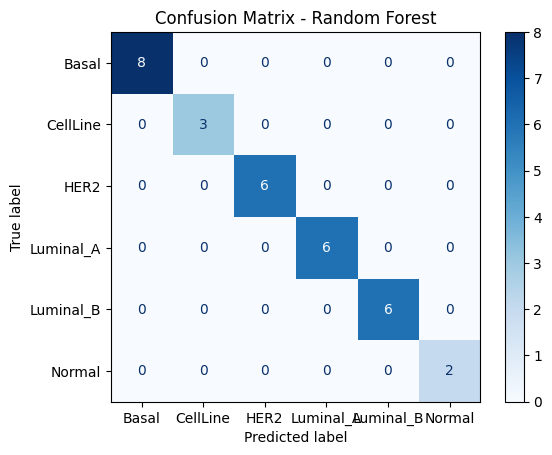

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [29]:
feature_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Gene,Importance
18534,223523_at,0.004189
14714,218195_at,0.003611
9352,209604_s_at,0.003328
11240,212496_s_at,0.003293
6816,205225_at,0.003287
25089,233388_at,0.003219
20611,226192_at,0.003183
18759,223892_s_at,0.003151
14825,218309_at,0.003132
13663,216088_s_at,0.003123


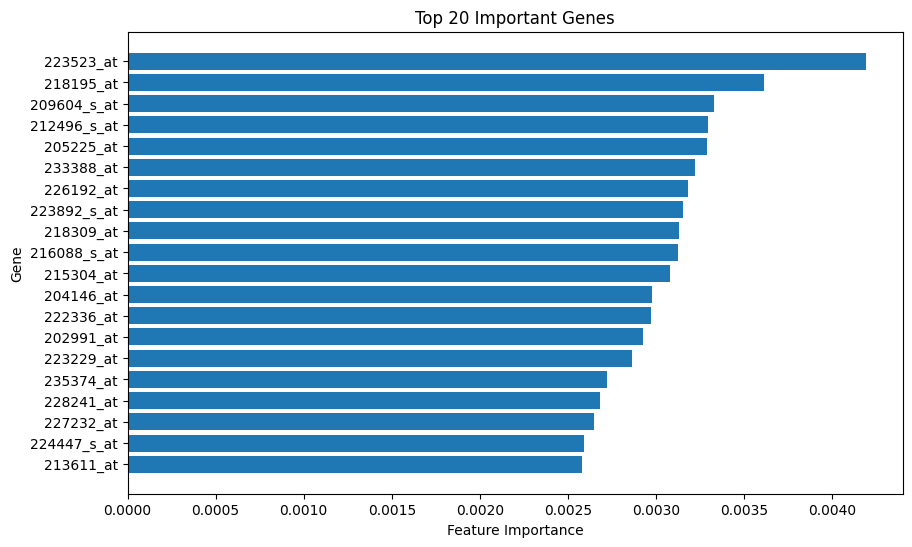

In [30]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["Gene"], top20["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Gene")
plt.title("Top 20 Important Genes")
plt.gca().invert_yaxis()
plt.show()

In [32]:
feature_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Gene,Importance
18534,223523_at,0.004189
14714,218195_at,0.003611
9352,209604_s_at,0.003328
11240,212496_s_at,0.003293
6816,205225_at,0.003287
25089,233388_at,0.003219
20611,226192_at,0.003183
18759,223892_s_at,0.003151
14825,218309_at,0.003132
13663,216088_s_at,0.003123


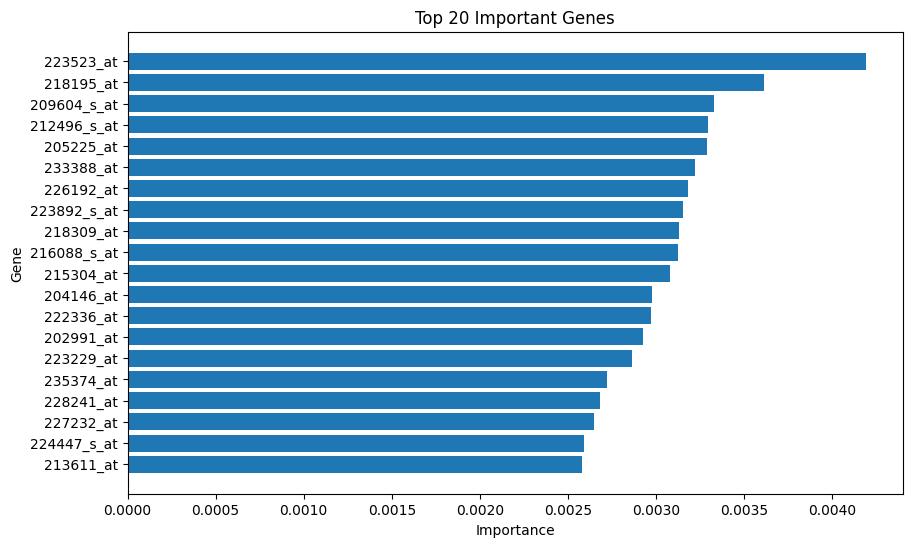

In [33]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["Gene"], top20["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.title("Top 20 Important Genes")
plt.show()

# Conclusion

This project demonstrates the application of machine learning to classify breast cancer subtypes using gene expression data from the GEO dataset GSE45827.

## Summary

- Parsed and processed a public GEO gene expression dataset.
- Extracted 29,873 gene expression features from 155 samples.
- Assigned six biological class labels.
- Built a Random Forest classifier.
- Evaluated the model using accuracy, precision, recall, and F1-score.
- Identified the most influential genes through feature importance analysis.

## Results

Random Forest achieved excellent classification performance on the held-out test set, highlighting the strong discriminatory power of gene expression profiles for breast cancer subtype classification.

This project demonstrates the integration of bioinformatics, data preprocessing, machine learning, and biological data interpretation.

## Limitations

- The dataset contains only 155 samples.
- Performance was evaluated on a single dataset.
- External validation using independent datasets was not performed.
- Feature importance indicates predictive value but does not establish biological causality.